In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs_tegfr_aggavg"
data = "dream_cytof"
filename = "evaluate_all_figure5"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
df.model.fillna(model, inplace=True)  # single model investigated in this batch of runs

In [5]:
df

,dataset,ref,model,samples,context,features,n_hidden,depth,multiheaded,dropout_rate,l1reg_inflater_output,l2reg_inflater_output,recon_loss,inflater_output_reg_epoch,job,n_epoch,inflater_bound,rmse
0,train,DMM,EGFR_MAPK__logobs_tegfr_aggavg,184A1,cytof_init,RFE_15_permute,8.0,0.0,False,0.1,0.01,0.0,0.0001,200.0,0.0,500.0,3.0,0.373837
1543,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,HCC1500,cytof_init,RFE_15_permute,8.0,0.0,False,0.1,0.01,0.0,0.0001,200.0,3.0,500.0,3.0,0.233814
1544,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,HCC1500,cytof_init,RFE_15_permute,8.0,0.0,False,0.1,0.01,0.0,0.0001,200.0,4.0,500.0,3.0,0.255547
1545,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,HCC1500,cytof_init,RFE_15_permute,8.0,0.0,False,0.1,0.01,0.0,0.0001,200.0,5.0,500.0,3.0,0.254977
1546,val,DMM,EGFR_MAPK__logobs_tegfr_aggavg,HCC1500,cytof_init,RFE_15_permute,8.0,0.0,False,0.1,0.01,0.0,0.0001,200.0,6.0,500.0,3.0,0.254407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,val,sample,EGFR_MAPK__logobs_tegfr_aggavg,HCC2218,multimodal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.260723
31,train,sample,EGFR_MAPK__logobs_tegfr_aggavg,HCC1187,cytof_init,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.302647
921,val,sample,EGFR_MAPK__logobs_tegfr_aggavg,HCC2185,multimodal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.418044
929,val,sample,EGFR_MAPK__logobs_tegfr_aggavg,HCC70,multimodal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.378569


In [2]:
train_df = df[df.dataset == "train"]
train_df.features.fillna("None", inplace=True)

val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

In [4]:
val_df.groupby(["ref", "model", "context", "features", "samples"]).rmse.mean()

ref     model                           context     features        samples 
DMM     EGFR_MAPK__logobs_tegfr_aggavg  cytof_init  RFE_15_permute  184A1       0.382475
                                                                    184B5       0.551047
                                                                    AU565       0.554843
                                                                    BT20        0.484522
                                                                    BT474       0.461320
                                                                                  ...   
sample  EGFR_MAPK__logobs_tegfr_aggavg  multimodal  None            UACC3199    0.376904
                                                                    UACC812     0.238494
                                                                    UACC893     0.216175
                                                                    ZR751       0.368664
                                 

In [6]:
dmm_df = df[df.ref == "DMM"]

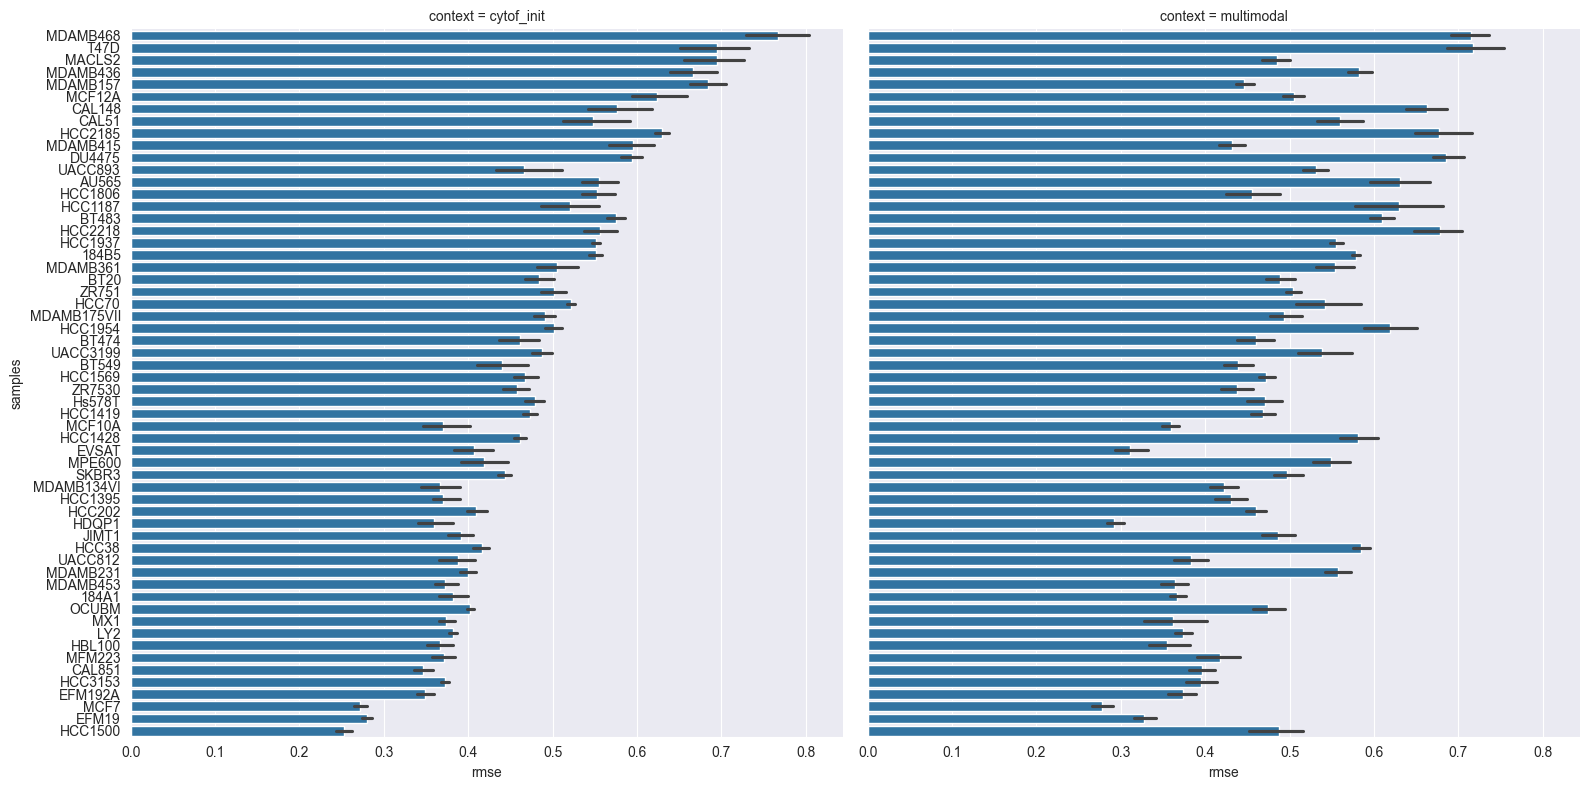

In [14]:
g = sns.FacetGrid(
    dmm_df[dmm_df.dataset == "val"].sort_values(by="rmse", ascending=False),
    col="context",
    col_order=["cytof_init", "multimodal"],
    height=8
)

g.map_dataframe(
    sns.barplot,
    x="rmse",
    y="samples",
)

In [18]:
import pandas as pd
from common import evaluations_dir

# Load only the per-cell-line/condition/observable RMSE dataset
by_df = pd.read_csv(evaluations_dir / model / data / "by_cl_cond_obs_figure5.csv")

# Basic cleaning
by_df = by_df.rename(columns={"samples": "cell_line"})

# Ensure dataset column has "train" and "val"
assert set(by_df["dataset"].unique()) <= {"train", "val"}

# -------------------------------------------------------------------
# 1. Compute RMSE_seen and RMSE_unseen per cell-line and context
# -------------------------------------------------------------------
agg = (
    by_df
    .groupby(["cell_line", "context", "dataset"])
    .agg(mean_rmse=("rmse", "mean"))
    .reset_index()
)

# Pivot so we get columns: train_rmse, val_rmse
pivot = (
    agg
    .pivot_table(
        index=["cell_line", "context"],
        columns="dataset",
        values="mean_rmse"
    )
    .reset_index()
    .rename(columns={"train": "rmse_seen", "val": "rmse_unseen"})
)

# Compute generalisation gap
pivot["generalisation_gap"] = pivot["rmse_unseen"] - pivot["rmse_seen"]

print("\n=== Per-cell-line generalisation gap (using only by_cl_cond_obs_figure5.csv) ===")
print(pivot.sort_values("generalisation_gap", ascending=False))


=== Per-cell-line generalisation gap (using only by_cl_cond_obs_figure5.csv) ===
dataset cell_line     context  rmse_seen  rmse_unseen  generalisation_gap
72         MCF12A  cytof_init   0.353793     0.728721            0.374927
105          T47D  multimodal   0.346471     0.716783            0.370312
104          T47D  cytof_init   0.373421     0.702548            0.329126
53        HCC2218  multimodal   0.315210     0.628526            0.313316
73         MCF12A  multimodal   0.338989     0.644081            0.305092
..            ...         ...        ...          ...                 ...
66            LY2  cytof_init   0.383415     0.347139           -0.036276
60          HDQP1  cytof_init   0.346179     0.309087           -0.037092
61          HDQP1  multimodal   0.329995     0.286066           -0.043929
28         HBL100  cytof_init   0.359224     0.313331           -0.045894
24        EFM192A  cytof_init   0.346565     0.297216           -0.049349

[116 rows x 5 columns]


In [23]:
pivot[pivot.context == "cytof_init"].sort_values(by="generalisation_gap", ascending=False)

dataset,cell_line,context,rmse_seen,rmse_unseen,generalisation_gap
72,MCF12A,cytof_init,0.353793,0.728721,0.374927
104,T47D,cytof_init,0.373421,0.702548,0.329126
42,HCC1806,cytof_init,0.347039,0.639479,0.292440
92,MDAMB468,cytof_init,0.344408,0.636565,0.292156
58,HCC70,cytof_init,0.346889,0.621243,0.274354
34,HCC1419,cytof_init,0.340267,0.612110,0.271842
44,HCC1937,cytof_init,0.385255,0.630801,0.245545
50,HCC2185,cytof_init,0.349316,0.588062,0.238746
20,DU4475,cytof_init,0.335460,0.552324,0.216864
40,HCC1569,cytof_init,0.356967,0.571583,0.214616


In [24]:
pivot[pivot.context == "multimodal"].sort_values(by="generalisation_gap", ascending=False)

dataset,cell_line,context,rmse_seen,rmse_unseen,generalisation_gap
105,T47D,multimodal,0.346471,0.716783,0.370312
53,HCC2218,multimodal,0.315210,0.628526,0.313316
73,MCF12A,multimodal,0.338989,0.644081,0.305092
51,HCC2185,multimodal,0.334042,0.631722,0.297679
21,DU4475,multimodal,0.318998,0.612047,0.293049
59,HCC70,multimodal,0.330040,0.618129,0.288089
93,MDAMB468,multimodal,0.323579,0.605122,0.281544
35,HCC1419,multimodal,0.315890,0.594846,0.278956
45,HCC1937,multimodal,0.351436,0.620648,0.269212
41,HCC1569,multimodal,0.336230,0.597078,0.260848


In [25]:
agg = (
    by_df
    .groupby(["observable", "context", "dataset"])
    .agg(mean_rmse=("rmse", "mean"))
    .reset_index()
)

# Pivot so we get columns: train_rmse, val_rmse
pivot = (
    agg
    .pivot_table(
        index=["observable", "context"],
        columns="dataset",
        values="mean_rmse"
    )
    .reset_index()
    .rename(columns={"train": "rmse_seen", "val": "rmse_unseen"})
)

# Compute generalisation gap
pivot["generalisation_gap"] = pivot["rmse_unseen"] - pivot["rmse_seen"]

print("\n=== Per-cell-line generalisation gap (using only by_cl_cond_obs_figure5.csv) ===")
print(pivot.sort_values("generalisation_gap", ascending=False))


=== Per-cell-line generalisation gap (using only by_cl_cond_obs_figure5.csv) ===
dataset         observable     context  rmse_seen  rmse_unseen  \
7        pRPS6KA1_S380_obs  multimodal   0.400950     0.565716   
3            pERK_Y204_obs  multimodal   0.395389     0.523254   
6        pRPS6KA1_S380_obs  cytof_init   0.435309     0.562586   
1         pERBB2_Y1248_obs  multimodal   0.285047     0.386042   
2            pERK_Y204_obs  cytof_init   0.421172     0.517126   
5            pMEK_S222_obs  multimodal   0.234447     0.327069   
4            pMEK_S222_obs  cytof_init   0.242131     0.310884   
0         pERBB2_Y1248_obs  cytof_init   0.294321     0.341197   

dataset  generalisation_gap  
7                  0.164766  
3                  0.127866  
6                  0.127277  
1                  0.100995  
2                  0.095954  
5                  0.092622  
4                  0.068753  
0                  0.046876  


In [26]:
pivot

dataset,observable,context,rmse_seen,rmse_unseen,generalisation_gap
0,pERBB2_Y1248_obs,cytof_init,0.294321,0.341197,0.046876
1,pERBB2_Y1248_obs,multimodal,0.285047,0.386042,0.100995
2,pERK_Y204_obs,cytof_init,0.421172,0.517126,0.095954
3,pERK_Y204_obs,multimodal,0.395389,0.523254,0.127866
4,pMEK_S222_obs,cytof_init,0.242131,0.310884,0.068753
5,pMEK_S222_obs,multimodal,0.234447,0.327069,0.092622
6,pRPS6KA1_S380_obs,cytof_init,0.435309,0.562586,0.127277
7,pRPS6KA1_S380_obs,multimodal,0.400950,0.565716,0.164766


In [28]:
import pandas as pd

# Load dataset
by_df = pd.read_csv(evaluations_dir / model / data / "by_cl_cond_obs_figure5.csv")
by_df = by_df.rename(columns={"samples": "cell_line"})

# -------------------------------------------------------------------
# 1. aggregate rmse per (cell-line, condition, context, dataset)
#    across observables and jobs
# -------------------------------------------------------------------
cond_cl = (
    by_df
    .groupby(["cell_line", "condition", "context", "dataset"], as_index=False)
    .agg(mean_rmse=("rmse", "mean"))
)

# Pivot so we get columns "train" and "val"
cond_cl_pivot = cond_cl.pivot_table(
    index=["cell_line", "condition", "context"],
    columns="dataset",
    values="mean_rmse"
).reset_index()

# Rename columns
cond_cl_pivot = cond_cl_pivot.rename(
    columns={"train": "rmse_seen", "val": "rmse_unseen"}
)

# Drop missing values (if some combinations never appeared in train or val)
cond_cl_pivot = cond_cl_pivot.dropna(subset=["rmse_seen", "rmse_unseen"])

# Compute per-cell-line × condition generalisation gap
cond_cl_pivot["generalisation_gap"] = (
    cond_cl_pivot["rmse_unseen"] - cond_cl_pivot["rmse_seen"]
)

print("=== Per-cell-line × condition generalisation gaps ===")
print(cond_cl_pivot.sort_values("generalisation_gap", ascending=False).head(20))

=== Per-cell-line × condition generalisation gaps ===
dataset cell_line condition     context  rmse_seen  rmse_unseen  \
155       HCC2185      iMEK  multimodal   0.320117     0.929366   
65         DU4475      iMEK  multimodal   0.315476     0.851227   
154       HCC2185      iMEK  cytof_init   0.341989     0.856296   
104       HCC1419     iEGFR  cytof_init   0.360862     0.784084   
317          T47D      iMEK  multimodal   0.328918     0.748290   
11          184B5      iMEK  multimodal   0.321293     0.718126   
216        MCF12A       EGF  cytof_init   0.335940     0.720825   
220        MCF12A      iMEK  cytof_init   0.351223     0.733085   
94        HCC1187      iMEK  cytof_init   0.339899     0.712029   
316          T47D      iMEK  cytof_init   0.360742     0.726652   
280      MDAMB468      iMEK  cytof_init   0.345203     0.707243   
217        MCF12A       EGF  multimodal   0.325244     0.685279   
218        MCF12A     iEGFR  cytof_init   0.374181     0.732252   
159     

In [29]:
cond_cl_pivot

dataset,cell_line,condition,context,rmse_seen,rmse_unseen,generalisation_gap
0,184A1,EGF,cytof_init,0.327153,0.331936,0.004783
1,184A1,EGF,multimodal,0.309444,0.336118,0.026675
2,184A1,iEGFR,cytof_init,0.366519,0.377051,0.010532
3,184A1,iEGFR,multimodal,0.346737,0.398894,0.052157
4,184A1,iMEK,cytof_init,0.344451,0.361443,0.016992
...,...,...,...,...,...,...
343,ZR7530,EGF,multimodal,0.321181,0.304116,-0.017064
344,ZR7530,iEGFR,cytof_init,0.374178,0.465464,0.091286
345,ZR7530,iEGFR,multimodal,0.356993,0.427363,0.070371
346,ZR7530,iMEK,cytof_init,0.350920,0.385850,0.034930


In [30]:
# -------------------------------------------------------------------
# 2. aggregate rmse per (cell-line, observable, context, dataset)
#    across conditions and jobs
# -------------------------------------------------------------------
obs_cl = (
    by_df
    .groupby(["cell_line", "observable", "context", "dataset"], as_index=False)
    .agg(mean_rmse=("rmse", "mean"))
)

# Pivot train/val into columns
obs_cl_pivot = obs_cl.pivot_table(
    index=["cell_line", "observable", "context"],
    columns="dataset",
    values="mean_rmse"
).reset_index()

obs_cl_pivot = obs_cl_pivot.rename(
    columns={"train": "rmse_seen", "val": "rmse_unseen"}
)

obs_cl_pivot = obs_cl_pivot.dropna(subset=["rmse_seen", "rmse_unseen"])

# Compute per-cell-line × observable gap
obs_cl_pivot["generalisation_gap"] = (
    obs_cl_pivot["rmse_unseen"] - obs_cl_pivot["rmse_seen"]
)

print("=== Per-cell-line × observable generalisation gaps ===")
print(obs_cl_pivot.sort_values("generalisation_gap", ascending=False).head(20))

=== Per-cell-line × observable generalisation gaps ===
dataset cell_line         observable     context  rmse_seen  rmse_unseen  \
209       HCC2218   pERBB2_Y1248_obs  multimodal   0.253737     0.932885   
208       HCC2218   pERBB2_Y1248_obs  cytof_init   0.264688     0.893362   
63         CAL148  pRPS6KA1_S380_obs  multimodal   0.421322     1.012512   
419          T47D      pERK_Y204_obs  multimodal   0.408932     0.972002   
278        MACLS2  pRPS6KA1_S380_obs  cytof_init   0.428378     0.952918   
207       HCC2185  pRPS6KA1_S380_obs  multimodal   0.400667     0.919074   
127       HCC1187  pRPS6KA1_S380_obs  multimodal   0.391828     0.890723   
385        MPE600   pERBB2_Y1248_obs  multimodal   0.277842     0.771091   
314      MDAMB157      pERK_Y204_obs  cytof_init   0.440686     0.915465   
418          T47D      pERK_Y204_obs  cytof_init   0.443598     0.905657   
206       HCC2185  pRPS6KA1_S380_obs  cytof_init   0.422832     0.858432   
290        MCF12A      pERK_Y204_

In [32]:
obs_cl_pivot

dataset,cell_line,observable,context,rmse_seen,rmse_unseen,generalisation_gap
0,184A1,pERBB2_Y1248_obs,cytof_init,0.298475,0.299588,0.001113
1,184A1,pERBB2_Y1248_obs,multimodal,0.289944,0.318958,0.029014
2,184A1,pERK_Y204_obs,cytof_init,0.409232,0.403927,-0.005304
3,184A1,pERK_Y204_obs,multimodal,0.383669,0.433580,0.049911
4,184A1,pMEK_S222_obs,cytof_init,0.233640,0.301874,0.068234
...,...,...,...,...,...,...
459,ZR7530,pERK_Y204_obs,multimodal,0.397871,0.486554,0.088682
460,ZR7530,pMEK_S222_obs,cytof_init,0.246370,0.241797,-0.004573
461,ZR7530,pMEK_S222_obs,multimodal,0.236094,0.256916,0.020822
462,ZR7530,pRPS6KA1_S380_obs,cytof_init,0.442168,0.485168,0.043000


In [33]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs_tegfr_aggavg", data="dream_cytof"))
del petab_base_files["condition_table"]
samples = get_samples("dream_cytof")

cytof_init, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples,
    features=None,
    **petab_base_files,
)

In [53]:
def build_targets_df(
    by_df: pd.DataFrame,
    cytof_init: pd.DataFrame,
    context: str = "cytof_init",
    metric: str = "unseen",
) -> pd.DataFrame:
    """
    Build a multi-task regression target matrix.

    Rows   = cell-lines (aligned with cytof_init.index)
    Cols   = all (condition, observable) pairs for the chosen context
    Values = chosen metric per (cell-line, condition, observable):
             - "unseen": RMSE on dataset == "val"
             - "seen"  : RMSE on dataset == "train"
             - "gap"   : RMSE_unseen - RMSE_seen
    """
    df = by_df.copy()

    # Restrict to the desired context (cytof_init vs multimodal)
    df = df[df["context"] == context]

    # Aggregate over jobs, replicates, etc. for stability
    df_agg = (
        df.groupby(["cell_line", "condition", "observable", "dataset"], as_index=False)
          .agg(mean_rmse=("rmse", "mean"))
    )

    # Pivot dataset -> train/val columns
    pivot = df_agg.pivot_table(
        index=["cell_line", "condition", "observable"],
        columns="dataset",
        values="mean_rmse",
    ).reset_index()

    # Rename columns for clarity; some combos may be missing train/val
    pivot = pivot.rename(columns={"train": "rmse_seen", "val": "rmse_unseen"})

    # We only want rows where both seen and unseen exist (for "gap"),
    # but for "seen" or "unseen" you could relax this if you like.
    if metric == "gap":
        pivot = pivot.dropna(subset=["rmse_seen", "rmse_unseen"])

    # Choose the target metric
    if metric == "unseen":
        pivot["target"] = pivot["rmse_unseen"]
    elif metric == "seen":
        pivot["target"] = pivot["rmse_seen"]
    elif metric == "gap":
        pivot["target"] = pivot["rmse_unseen"] - pivot["rmse_seen"]
    else:
        raise ValueError(f"Unknown metric: {metric!r} (use 'unseen', 'seen', or 'gap')")

    # Wide format: one row per cell-line, one column per (condition, observable)
    wide = pivot.pivot_table(
        index="cell_line",
        columns=["condition", "observable"],
        values="target",
    )

    # Flatten MultiIndex columns: e.g. "EGF_10ng__pERK"
    wide.columns = [
        f"{cond}__{obs}"
        for (cond, obs) in wide.columns.to_list()
    ]

    # Align cell-lines between cytof_init and the targets
    # (assuming cytof_init index are cell-line names)
    cytof_init = cytof_init.reset_index()
    cytof_init.preequilibrationConditionId = cytof_init.preequilibrationConditionId.apply(lambda x: x[1:])
    cytof_init.set_index("preequilibrationConditionId", inplace=True)
    cell_lines_inputs = set(cytof_init.index)
    cell_lines_targets = set(wide.index)
    common_cell_lines = sorted(cell_lines_inputs & cell_lines_targets)

    # Subset & align
    targets_df = wide.loc[common_cell_lines].sort_index()
    # You’ll want your X to be aligned too:
    inputs_aligned = cytof_init.loc[common_cell_lines].sort_index()

    return inputs_aligned, targets_df

In [120]:
# X_inputs is your cytof_init restricted to cell-lines with targets
# Y_targets is the multi-task target matrix (one column per cond/obs)
X_inputs, Y_targets = build_targets_df(
    by_df=by_df,
    cytof_init=cytof_init,
    context="cytof_init",   # or "multimodal"
    metric="gap",           # "unseen", "seen", or "gap"
)

print(X_inputs.shape)  # (n_cells, n_features)
print(Y_targets.shape) # (n_cells, n_conditions * n_observables)

(58, 37)
(58, 12)


In [103]:
# X_inputs.drop(columns=["b.CATENIN"], inplace=True)
X_inputs = X_inputs[["b.CATENIN"]]

In [104]:
X_inputs

,b.CATENIN
preequilibrationConditionId,
184A1,1.199649
184B5,0.787387
AU565,0.789467
BT20,1.070486
BT474,1.157233
BT483,1.066758
BT549,0.706808
CAL148,1.120135
CAL51,1.142842


In [105]:
Y_targets

,EGF__pERBB2_Y1248_obs,EGF__pERK_Y204_obs,EGF__pMEK_S222_obs,EGF__pRPS6KA1_S380_obs,iEGFR__pERBB2_Y1248_obs,iEGFR__pERK_Y204_obs,iEGFR__pMEK_S222_obs,iEGFR__pRPS6KA1_S380_obs,iMEK__pERBB2_Y1248_obs,iMEK__pERK_Y204_obs,iMEK__pMEK_S222_obs,iMEK__pRPS6KA1_S380_obs
cell_line,,,,,,,,,,,,
184A1,-0.066683,-0.039883,0.007336,0.129022,0.098517,-0.010264,0.049183,-0.078754,-0.029552,0.034233,0.148182,-0.075699
184B5,0.052077,0.190000,0.145805,0.194581,0.025855,0.170111,0.089716,0.205593,NaN,0.392233,0.135462,0.224382
AU565,0.055465,0.325044,0.068207,0.225794,0.033705,0.196259,0.019395,-0.058511,0.021354,0.415329,-0.037530,0.385709
BT20,0.502734,0.079409,0.205020,-0.048038,-0.020120,0.095675,0.162468,-0.003117,0.610354,-0.112367,0.461324,0.167522
BT474,-0.025910,-0.103573,-0.016369,0.230034,-0.013696,0.081314,-0.034630,0.283520,-0.053109,0.140348,-0.014941,0.340629
BT483,NaN,0.212933,-0.059684,0.392807,NaN,0.026593,-0.008308,0.380300,NaN,-0.079147,0.088453,-0.151347
BT549,-0.084998,-0.096966,0.080851,0.021184,-0.038125,0.041119,0.082232,0.140489,-0.113647,-0.032156,-0.028119,0.285846
CAL148,0.091818,0.107978,0.027480,0.352042,0.128432,0.012880,-0.055041,0.257764,0.073337,0.340156,-0.002607,0.538940
CAL51,-0.115765,0.296938,0.008297,0.373168,-0.107587,0.048309,0.002251,0.247497,-0.087652,0.142614,0.098909,0.072456


In [121]:
import jax
import jax.numpy as jnp
from jax import jit, grad, value_and_grad
import optax

# X_inputs: (n_cells, n_features)        — cytof_init features
# Y_targets: (n_cells, n_tasks)          — target RMSEs, many NaNs
import numpy as np

X = np.asarray(X_inputs.values, dtype=np.float32)
Y = np.asarray(Y_targets.values, dtype=np.float32)

# Mask: True where target is valid
mask = ~np.isnan(Y)

# Replace NaNs with zeros (safe — mask removes them from training)
Y = np.nan_to_num(Y, nan=0.0)

def init_params(n_features, n_tasks, key=0):
    key = jax.random.PRNGKey(key)
    W = jax.random.normal(key, (n_tasks, n_features)) * 0.01
    b = jnp.zeros((n_tasks,))
    return {"W": W, "b": b}

def predict(params, X):
    # X: (n_cells, n_features)
    # W: (n_tasks, n_features)
    return X @ params["W"].T + params["b"]  # → (n_cells, n_tasks)

def masked_mse(params, X, Y, mask):
    preds = predict(params, X)
    diff = (preds - Y) ** 2
    diff = diff * mask  # zero-out missing targets
    return jnp.sum(diff) / jnp.sum(mask)

def train_model(X, Y, mask, lr=1e-2, steps=5000):
    n_cells, n_features = X.shape
    n_tasks = Y.shape[1]

    params = init_params(n_features, n_tasks)
    opt = optax.adam(lr)
    opt_state = opt.init(params)

    @jit
    def update(params, opt_state, X, Y, mask):
        loss, grads = value_and_grad(masked_mse)(params, X, Y, mask)
        updates, opt_state = opt.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss

    for step in range(steps):
        params, opt_state, loss = update(params, opt_state, X, Y, mask)
        if step % 500 == 0:
            print(f"Step {step} | Loss {loss:.4f}")

    return params

params = train_model(X, Y, mask, lr=2e-2, steps=5000)

Step 0 | Loss 0.0903
Step 500 | Loss 0.0136
Step 1000 | Loss 0.0098
Step 1500 | Loss 0.0083
Step 2000 | Loss 0.0150
Step 2500 | Loss 0.0073
Step 3000 | Loss 0.0069
Step 3500 | Loss 0.0068
Step 4000 | Loss 0.0067
Step 4500 | Loss 0.0066


In [107]:
W = np.array(params["W"])   # shape (n_tasks, n_features)
b = np.array(params["b"])   # shape (n_tasks,)

In [108]:
import pandas as pd
task_names = list(Y_targets.columns)
coef_df = pd.DataFrame(
    W,
    index=task_names,
    columns=X_inputs.columns
)

<Axes: >

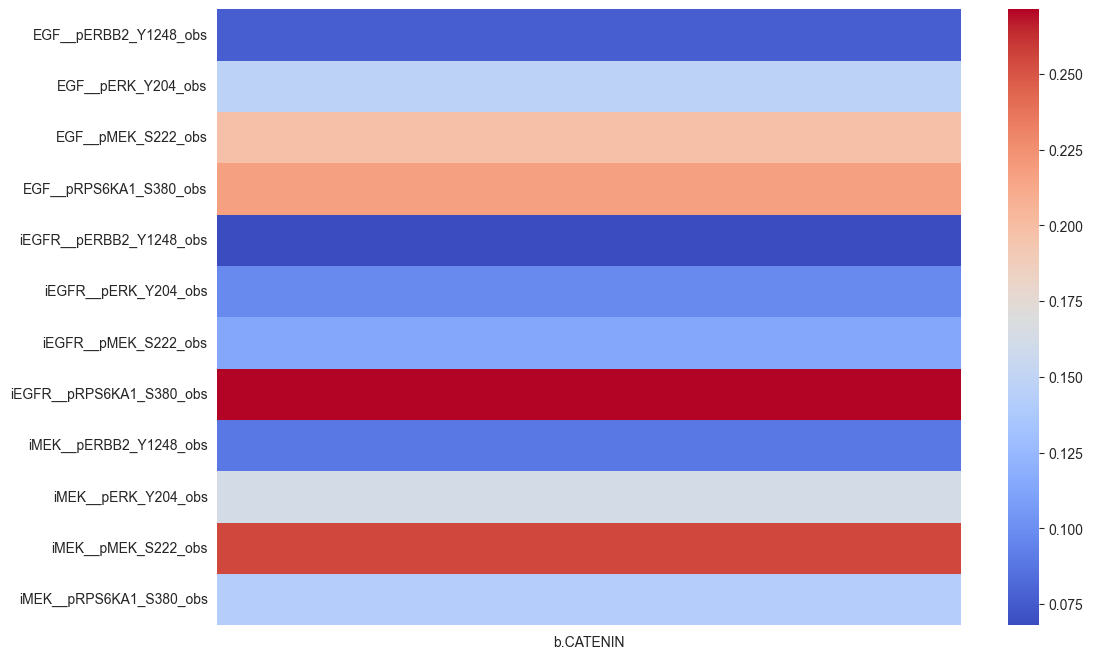

In [109]:
plt.figure(figsize=(12, 8))
sns.heatmap(coef_df, cmap="coolwarm", xticklabels=True, yticklabels=True)

In [112]:
def masked_r2(params, X, Y, mask):
    """
    Masked R^2 over all tasks jointly.
    """
    preds = predict(params, X)
    # Apply mask
    preds_masked = preds[mask]
    Y_masked = Y[mask]

    # Total sum of squares (around mean of Y)
    y_mean = jnp.mean(Y_masked)
    ss_tot = jnp.sum((Y_masked - y_mean) ** 2)

    # Residual sum of squares
    ss_res = jnp.sum((Y_masked - preds_masked) ** 2)

    return 1.0 - ss_res / ss_tot

In [122]:
import numpy as np
import jax.numpy as jnp

def kfold_indices(n_samples, n_folds=5, seed=0):
    rng = np.random.default_rng(seed)
    indices = np.arange(n_samples)
    rng.shuffle(indices)
    folds = np.array_split(indices, n_folds)
    return folds

def cross_validate_masked_linear(
    X_np,
    Y_np,
    mask_np,
    n_folds=5,
    lr=2e-2,
    steps=2000,
    seed=0,
):
    """
    X_np   : numpy array (n_cells, n_features)
    Y_np   : numpy array (n_cells, n_tasks)
    mask_np: numpy bool array (n_cells, n_tasks)
    """

    n_cells = X_np.shape[0]
    folds = kfold_indices(n_cells, n_folds=n_folds, seed=seed)

    val_losses = []
    val_r2s = []

    for i in range(n_folds):
        val_idx = folds[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(n_folds) if j != i]
        )

        X_train = jnp.asarray(X_np[train_idx], dtype=jnp.float32)
        Y_train = jnp.asarray(Y_np[train_idx], dtype=jnp.float32)
        mask_train = jnp.asarray(mask_np[train_idx])

        X_val = jnp.asarray(X_np[val_idx], dtype=jnp.float32)
        Y_val = jnp.asarray(Y_np[val_idx], dtype=jnp.float32)
        mask_val = jnp.asarray(mask_np[val_idx])

        print(f"\n=== Fold {i+1}/{n_folds}: train {len(train_idx)}, val {len(val_idx)} ===")
        params = train_model(X_train, Y_train, mask_train, lr=lr, steps=steps)

        # Validation metrics
        val_loss = masked_mse(params, X_val, Y_val, mask_val)
        val_r2 = masked_r2(params, X_val, Y_val, mask_val)

        val_losses.append(float(val_loss))
        val_r2s.append(float(val_r2))

        print(f"Fold {i+1} | val masked MSE = {val_loss:.4f} | val masked R^2 = {val_r2:.4f}")

    print("\n=== Cross-validation summary ===")
    print(f"Mean val masked MSE: {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")
    print(f"Mean val masked R^2: {np.mean(val_r2s):.4f} ± {np.std(val_r2s):.4f}")

    return {
        "val_losses": np.array(val_losses),
        "val_r2s": np.array(val_r2s),
    }

In [123]:
cv_results = cross_validate_masked_linear(
    X_np=X,
    Y_np=Y,
    mask_np=mask,
    n_folds=5,
    lr=2e-2,
    steps=2000,   # you can play with this
    seed=42,
)


=== Fold 1/5: train 46, val 12 ===
Step 0 | Loss 0.0918
Step 500 | Loss 0.0106
Step 1000 | Loss 0.0070
Step 1500 | Loss 0.0057
Fold 1 | val masked MSE = 0.0644 | val masked R^2 = -1.2311

=== Fold 2/5: train 46, val 12 ===
Step 0 | Loss 0.0796
Step 500 | Loss 0.0104
Step 1000 | Loss 0.0062
Step 1500 | Loss 0.0048
Fold 2 | val masked MSE = 0.0842 | val masked R^2 = -1.2801

=== Fold 3/5: train 46, val 12 ===
Step 0 | Loss 0.0902
Step 500 | Loss 0.0107
Step 1000 | Loss 0.0073
Step 1500 | Loss 0.0059
Fold 3 | val masked MSE = 0.0628 | val masked R^2 = -0.7425

=== Fold 4/5: train 47, val 11 ===
Step 0 | Loss 0.0979
Step 500 | Loss 0.0123
Step 1000 | Loss 0.0077
Step 1500 | Loss 0.0058
Fold 4 | val masked MSE = 0.0622 | val masked R^2 = -3.1556

=== Fold 5/5: train 47, val 11 ===
Step 0 | Loss 0.0919
Step 500 | Loss 0.0119
Step 1000 | Loss 0.0078
Step 1500 | Loss 0.0060
Fold 5 | val masked MSE = 0.0704 | val masked R^2 = -1.3021

=== Cross-validation summary ===
Mean val masked MSE: 0.068

In [135]:
import pandas as pd
from common import evaluations_dir

# Load only the per-cell-line/condition/observable RMSE dataset
by_df = pd.read_csv(evaluations_dir / model / data / "by_cl_cond_obs_figure5.csv")

# Basic cleaning
by_df = by_df.rename(columns={"samples": "cell_line"})

# Ensure dataset column has "train" and "val"
assert set(by_df["dataset"].unique()) <= {"train", "val"}

# -------------------------------------------------------------------
# 1. Compute RMSE_seen and RMSE_unseen per cell-line and context
# -------------------------------------------------------------------
agg = (
    by_df
    .groupby(["cell_line", "context", "dataset"])
    .agg(mean_rmse=("rmse", "mean"))
    .reset_index()
)

# Pivot so we get columns: train_rmse, val_rmse
pivot = (
    agg
    .pivot_table(
        index=["cell_line", "context"],
        columns="dataset",
        values="mean_rmse"
    )
    .reset_index()
    .rename(columns={"train": "rmse_seen", "val": "rmse_unseen"})
)

# Compute generalisation gap
pivot["generalisation_gap"] = pivot["rmse_unseen"] - pivot["rmse_seen"]
pivot.reset_index()
pivot.set_index("cell_line", inplace=True)

In [136]:
pivot

dataset,context,rmse_seen,rmse_unseen,generalisation_gap
cell_line,,,,
184A1,cytof_init,0.346048,0.356810,0.010761
184A1,multimodal,0.324485,0.357504,0.033019
184B5,cytof_init,0.354506,0.519810,0.165304
184B5,multimodal,0.332703,0.546381,0.213678
AU565,cytof_init,0.374715,0.509434,0.134718
...,...,...,...,...
UACC893,multimodal,0.322724,0.470520,0.147796
ZR751,cytof_init,0.353763,0.445205,0.091442
ZR751,multimodal,0.337225,0.441247,0.104022


In [157]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from common import evaluations_dir

# assuming file_id_table / dftrans / dfprot / seqvar_df still live elsewhere
# and you may or may not want to use them here


def plot_residuals(model, context, gap_threshold=0.0,
                   metric="euclidean", method="average"):
    """
    Clustermap of per-cell-line generalisation gap, clustered on the gap.

    Parameters
    ----------
    model : str
        Model name (used with evaluations_dir / model / "data").
    context : str
        Biological context to filter on.
    gap_threshold : float, optional
        Keep only cell lines whose max |gap| across (condition, observable)
        exceeds this value. Set to 0.0 to keep all.
    metric : str, optional
        Distance metric for clustermap (rows).
    method : str, optional
        Linkage method for clustermap.
    """

    # ----------------------------------------------------------------------
    # Load and basic cleaning
    # ----------------------------------------------------------------------
    by_df = pd.read_csv(evaluations_dir / model / "dream_cytof" / "by_cl_cond_obs_figure5.csv")

    if "samples" in by_df.columns and "cell_line" not in by_df.columns:
        by_df = by_df.rename(columns={"samples": "cell_line"})

    required_cols = {"cell_line", "context", "dataset", "condition", "observable", "rmse"}
    missing = required_cols - set(by_df.columns)
    if missing:
        raise ValueError(f"Missing required columns in by_cl_cond_obs_figure5.csv: {missing}")

    # Only train/val
    assert set(by_df["dataset"].unique()) <= {"train", "val"}

    by_df = by_df[np.isfinite(by_df["rmse"])]
    by_df = by_df[by_df["context"] == context]

    if by_df.empty:
        raise ValueError(f"No rows found for context={context!r} in {model!r} evaluations.")

    # ----------------------------------------------------------------------
    # Build train / val / gap matrices
    # ----------------------------------------------------------------------
    dfp = by_df.pivot_table(
        index="cell_line",
        columns=["condition", "observable", "dataset"],
        values="rmse"
    )

    df_val = dfp.loc[:, dfp.columns.get_level_values("dataset") == "val"].copy()
    df_train = dfp.loc[:, dfp.columns.get_level_values("dataset") == "train"].copy()

    # Drop the dataset level -> columns = (condition, observable)
    df_val.columns = df_val.columns.droplevel("dataset")
    df_train.columns = df_train.columns.droplevel("dataset")

    # Ensure same columns
    df_train = df_train.reindex(columns=df_val.columns)

    df_gap = df_val - df_train

    # ----------------------------------------------------------------------
    # Filter cell lines by magnitude of gap, if desired
    # ----------------------------------------------------------------------
    if gap_threshold is not None and gap_threshold > 0.0:
        keep = df_gap.abs().max(axis=1) > gap_threshold
        df_gap = df_gap.loc[keep]

    # Drop completely-empty rows/cols (all NaNs)
    df_gap = df_gap.dropna(axis=0, how="all")  # rows
    df_gap = df_gap.dropna(axis=1, how="all")  # columns

    if df_gap.empty:
        raise ValueError(
            f"No cell lines left after filtering with |gap| max > {gap_threshold}."
        )

    # ----------------------------------------------------------------------
    # Handle remaining NaNs for clustering:
    # fill NaNs with 0 so that distance matrix is finite
    # (interpret missing gap as 0)
    # ----------------------------------------------------------------------
    if df_gap.isna().values.any():
        # If you prefer another strategy, e.g. column means:
        # df_gap = df_gap.fillna(df_gap.mean())
        df_gap = df_gap.fillna(0.0)

    # ----------------------------------------------------------------------
    # Clustermap on generalisation gap
    # ----------------------------------------------------------------------
    # symmetric colour range around 0
    max_abs_gap = np.nanmax(np.abs(df_gap.values))
    if not np.isfinite(max_abs_gap) or max_abs_gap == 0:
        max_abs_gap = 1.0

    cg = sns.clustermap(
        df_gap,
        metric=metric,
        method=method,
        cmap="coolwarm",
        center=0.0,
        vmin=-max_abs_gap,
        vmax=max_abs_gap,
        row_cluster=True,
        col_cluster=True,   # keep condition/observable order
        figsize=(12, 14),
        yticklabels=True,
        xticklabels=1,
    )

    cg.ax_heatmap.set_title(
        f"{model} – {context}\nPer-cell-line generalisation gap (val RMSE − train RMSE)"
    )
    cg.ax_heatmap.set_xlabel("condition / observable")
    cg.ax_heatmap.set_ylabel("cell line")

    plt.tight_layout()
    return cg

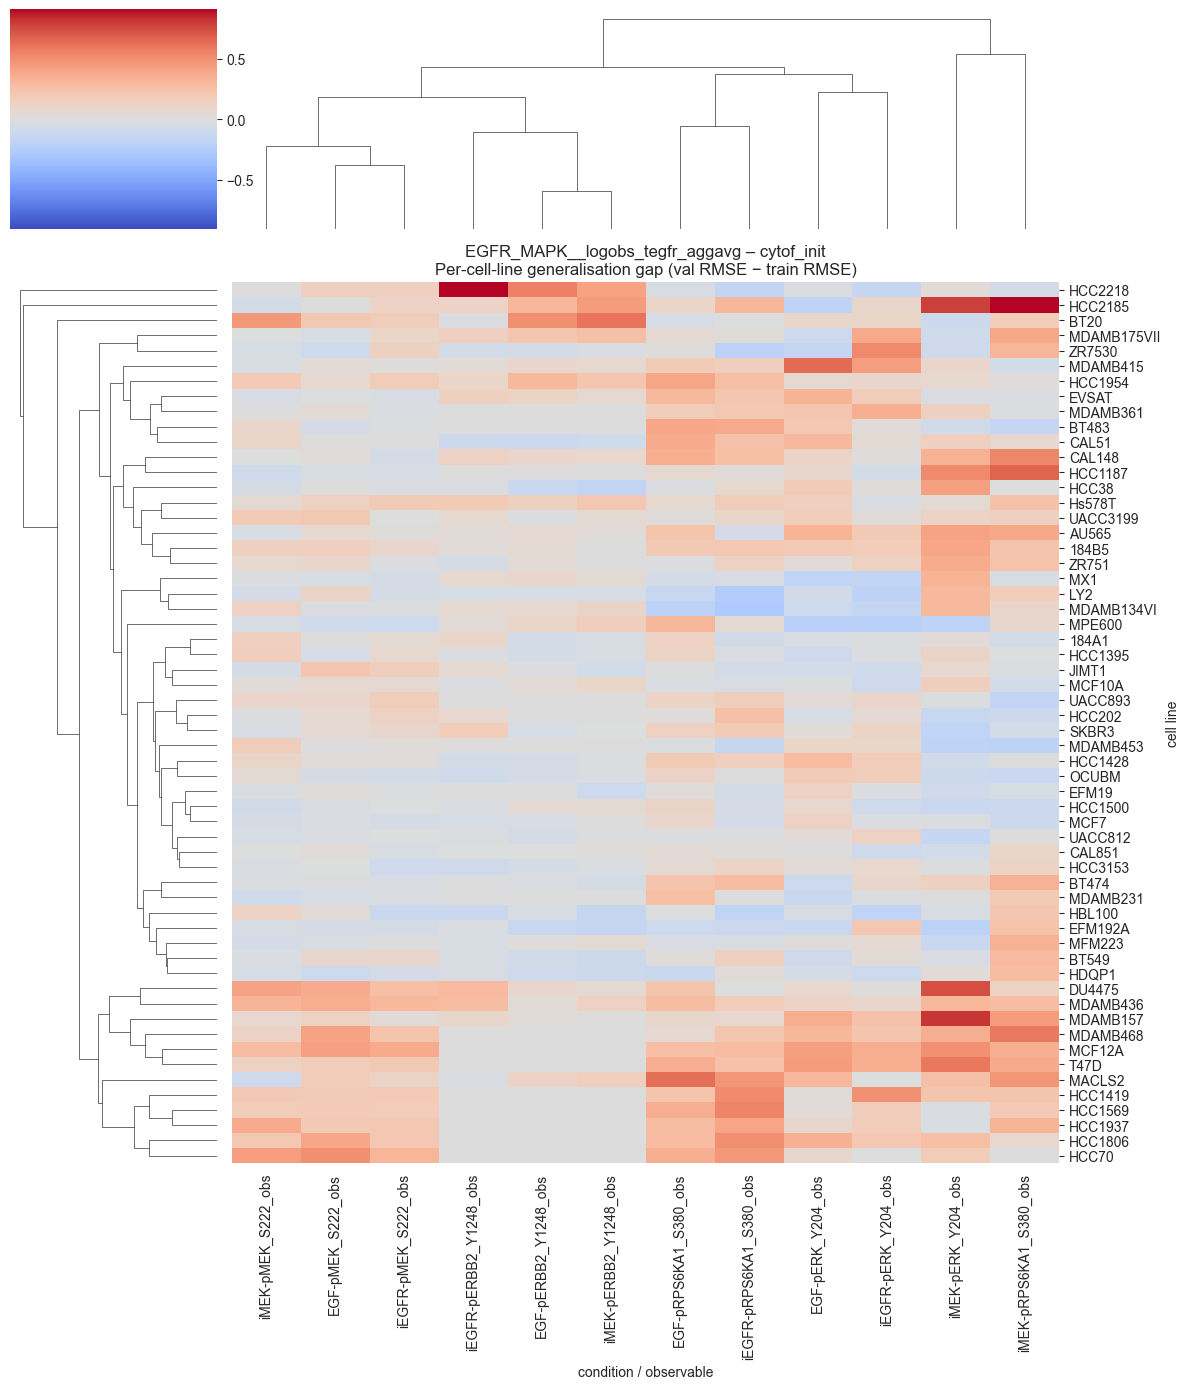

In [158]:
plot_residuals("EGFR_MAPK__logobs_tegfr_aggavg", context="cytof_init")

In [159]:
Y_targets

,EGF__pERBB2_Y1248_obs,EGF__pERK_Y204_obs,EGF__pMEK_S222_obs,EGF__pRPS6KA1_S380_obs,iEGFR__pERBB2_Y1248_obs,iEGFR__pERK_Y204_obs,iEGFR__pMEK_S222_obs,iEGFR__pRPS6KA1_S380_obs,iMEK__pERBB2_Y1248_obs,iMEK__pERK_Y204_obs,iMEK__pMEK_S222_obs,iMEK__pRPS6KA1_S380_obs
cell_line,,,,,,,,,,,,
184A1,-0.066683,-0.039883,0.007336,0.129022,0.098517,-0.010264,0.049183,-0.078754,-0.029552,0.034233,0.148182,-0.075699
184B5,0.052077,0.190000,0.145805,0.194581,0.025855,0.170111,0.089716,0.205593,NaN,0.392233,0.135462,0.224382
AU565,0.055465,0.325044,0.068207,0.225794,0.033705,0.196259,0.019395,-0.058511,0.021354,0.415329,-0.037530,0.385709
BT20,0.502734,0.079409,0.205020,-0.048038,-0.020120,0.095675,0.162468,-0.003117,0.610354,-0.112367,0.461324,0.167522
BT474,-0.025910,-0.103573,-0.016369,0.230034,-0.013696,0.081314,-0.034630,0.283520,-0.053109,0.140348,-0.014941,0.340629
BT483,NaN,0.212933,-0.059684,0.392807,NaN,0.026593,-0.008308,0.380300,NaN,-0.079147,0.088453,-0.151347
BT549,-0.084998,-0.096966,0.080851,0.021184,-0.038125,0.041119,0.082232,0.140489,-0.113647,-0.032156,-0.028119,0.285846
CAL148,0.091818,0.107978,0.027480,0.352042,0.128432,0.012880,-0.055041,0.257764,0.073337,0.340156,-0.002607,0.538940
CAL51,-0.115765,0.296938,0.008297,0.373168,-0.107587,0.048309,0.002251,0.247497,-0.087652,0.142614,0.098909,0.072456


In [165]:
from dmm.feature_selection import build_preprocessor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from typing import Union


def get_feature_importances(model, X, y, method="auto"):
    """
    Get feature importances for RandomForest or ElasticNet/LogisticRegression models.

    Parameters:
    - model: fitted sklearn model
    - method: 'auto', 'coef', 'tree', 'permutation'
    - X: input features (optional, needed for permutation importance)
    - y: target variable (optional, needed for permutation importance)

    Returns:
    - feature_importances: np.ndarray of shape (n_features,)
    """
    if method == "tree":
        return model.named_steps["regressor"].feature_importances_

    elif method == "permute":
        if X is None or y is None:
            raise ValueError(
                "X and y must be provided for permutation importance."
            )
        result = permutation_importance(
            model, X, y, n_repeats=10, random_state=42
        )
        return result.importances_mean

    else:
        raise ValueError(f"Unknown method: {method}")


def get_hvg(input_df: pd.DataFrame, top_n: Union[int, float] = 500) -> pd.DataFrame:
    # remove 20% of features with the lowest mean:
    means = np.mean(input_df, axis=0)
    threshold = np.percentile(means, 20)
    input_df = input_df.loc[:, means >= threshold]
    if isinstance(top_n, int):
        # Keep top N features with the highest variance
        var_threshold = sorted(
            np.nanvar(input_df, axis=0), reverse=True
        )[top_n]
        input_df = input_df.loc[
                     :, np.nanvar(input_df, axis=0) >= var_threshold
                     ]
    elif isinstance(top_n, float):
        perc = 100 * top_n
        # Keep top 50% features with the highest variance (default)
        var_threshold = np.percentile(np.nanvar(input_df, axis=0), perc)
        input_df = input_df.loc[
                     :, np.nanvar(input_df, axis=0) >= var_threshold
                     ]
    return input_df


def get_selected_features(
    input_data,
    output_data,
    context: str,
    features: str,
    features_all: list,
    cv=None,
):
    if features == "all":
        return features_all

    if features.startswith("RFE_") or features.startswith("HVGRFE_"):
        reduce_factor = 0.80
        # drop nans, this shouldnt do anything
        input_data = input_data.dropna(axis=1, how="any")
        if features.startswith("HVG") and context in [
            "proteomics",
            "transcriptomics",
        ]:
            input_data = get_hvg(input_data)

        output_data -= output_data.mean(axis=0)  # center output data

        n_features = int(features.split("_")[1])
        method = features.split("_")[2]
        random_state = 42  # For reproducibility
        estimator = RandomForestRegressor(
            random_state=random_state,
            max_features=reduce_factor,
        )
        pipeline = Pipeline(
            [("scaler", StandardScaler()), ("regressor", estimator)]
        )
        while input_data.shape[1] * reduce_factor > n_features:
            pipeline = pipeline.fit(input_data, output_data)
            y_pred = pipeline.predict(input_data)
            rmse = np.sqrt(np.mean(np.square(output_data.values - y_pred)))
            importances = get_feature_importances(
                pipeline,
                input_data,
                output_data,
                method=method if input_data.shape[1] <= 500 else "tree",
            )

            n_features_target = int(np.ceil(len(importances) * reduce_factor))
            if n_features_target == input_data.shape[1]:
                n_features_target -= 1  # reduce by at least one feature
            indices = np.argsort(importances)[::-1][:n_features_target]
            input_data = input_data.iloc[:, indices]
            print(
                f"Reduced features to: {input_data.shape[1]:>5} ({rmse:.2f})",
            )
        # Fit the final model with the selected features
        pipeline = pipeline.fit(input_data, output_data)
        importances = get_feature_importances(
            pipeline, input_data, output_data, method=method
        )
        indices = np.argsort(importances)[::-1][:n_features]
        return input_data.columns[indices]

    preprocessor = build_preprocessor(features, input_data, output_data, cv=cv)
    preprocessor = preprocessor.fit(input_data, output_data)

    return preprocessor.feature_names_in_[
        preprocessor.steps[-1][1].get_support()
    ]

In [199]:
proteomics, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)

In [208]:
selected_proteins = get_selected_features(
    input_data=proteomics.sort_index(),
    output_data=Y_targets.sort_index().dropna(axis=1),
    context="proteomics",
    features="HVGRFE_10_permute",
    features_all=None
)

Reduced features to:   401 (0.07)
Reduced features to:   321 (0.06)
Reduced features to:   257 (0.07)
Reduced features to:   206 (0.07)
Reduced features to:   165 (0.07)
Reduced features to:   132 (0.07)
Reduced features to:   106 (0.06)
Reduced features to:    85 (0.06)
Reduced features to:    68 (0.06)
Reduced features to:    55 (0.06)
Reduced features to:    44 (0.06)
Reduced features to:    36 (0.06)
Reduced features to:    29 (0.06)
Reduced features to:    24 (0.06)
Reduced features to:    20 (0.06)
Reduced features to:    16 (0.06)
Reduced features to:    13 (0.06)
Reduced features to:    11 (0.06)


In [177]:
transcriptomics, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)

In [209]:
selected_transcripts = get_selected_features(
    input_data=transcriptomics.sort_index(),
    output_data=Y_targets.sort_index().dropna(axis=1),
    context="transcriptomics",
    features="HVGRFE_10_permute",
    features_all=None
)

Reduced features to:   401 (0.07)
Reduced features to:   321 (0.07)
Reduced features to:   257 (0.07)
Reduced features to:   206 (0.06)
Reduced features to:   165 (0.06)
Reduced features to:   132 (0.06)
Reduced features to:   106 (0.06)
Reduced features to:    85 (0.06)
Reduced features to:    68 (0.07)
Reduced features to:    55 (0.06)
Reduced features to:    44 (0.06)
Reduced features to:    36 (0.06)
Reduced features to:    29 (0.06)
Reduced features to:    24 (0.06)
Reduced features to:    20 (0.06)
Reduced features to:    16 (0.06)
Reduced features to:    13 (0.06)
Reduced features to:    11 (0.06)


In [217]:
# selected_proteins = ['SHMT1', 'ABHD12', 'DPAGT1', 'RIOX1', 'HECTD1', 'ATP13A1', 'TERF2IP',
#        'CKS1B', 'NARS2', 'SPAG9']
# selected_transcripts = ['HOXB7', 'TMEM139', 'EYA2', 'KYNU', 'EEF1A2', 'CREB3L1', 'CYBA',
#        'ZG16B', 'IFITM2', 'TMTC1']
selected_genes = selected_proteins.values.tolist() + selected_transcripts.values.tolist()


import gseapy as gs
enr = gs.enrichr(
    gene_list=selected_genes,
    gene_sets=[
        "MSigDB_Hallmark_2020",
        "MSigDB_Oncogenic_Signatures",
        "KEGG_2021_Human",
        "Reactome_2022",
        "Reactome_Pathways_2024",
        "WikiPathways_2024_Human",
        "Jensen_COMPARTMENTS",
        "GO_Biological_Process_2025",
        "GO_Cellular_Component_2025",
        "GO_Molecular_Function_2025"
    ],
    background=list(proteomics.columns) + list(transcriptomics.columns),
    organism='Human',
    cutoff=0.05
)

In [213]:
results = enr.results
results[results["Adjusted P-value"] < 0.05].to_csv("enrichment_proteomics_transcriptomics_RMSEgap.csv")

In [218]:
results = enr.results
results[results["Adjusted P-value"] < 0.05]

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.000073,0.001307,0,0,21.799479,207.763114,SPARC;TIMP3;VIM;SNTB1
1,MSigDB_Hallmark_2020,UV Response Up,0.000748,0.004834,0,0,19.613946,141.184316,LYN;GPX3;CLTB
2,MSigDB_Hallmark_2020,Apoptosis,0.000806,0.004834,0,0,19.103226,136.086437,GPX3;TIMP3;PTK2
3,MSigDB_Hallmark_2020,Myogenesis,0.001331,0.005990,0,0,15.976789,105.793413,SPARC;GPX3;APOD
4,MSigDB_Hallmark_2020,Coagulation,0.009831,0.035392,0,0,14.821869,68.509646,SPARC;TIMP3
...,...,...,...,...,...,...,...,...,...
1359,GO_Molecular_Function_2025,Acid-Amino Acid Ligase Activity (GO:0016881),0.007058,0.046975,0,0,178.200000,882.728132,PPCS
1360,GO_Molecular_Function_2025,Endopeptidase Inhibitor Activity (GO:0004866),0.007088,0.046975,0,0,17.639413,87.304003,TIMP3;PI3
1361,GO_Molecular_Function_2025,Phosphorylation-Dependent Protein Binding (GO:...,0.008230,0.046975,0,0,148.491228,712.756370,LYN
1362,GO_Molecular_Function_2025,JUN Kinase Binding (GO:0008432),0.010569,0.046975,0,0,111.355263,506.643531,PTK2


In [215]:
selected_genes

['UQCC1',
 'TMEM97',
 'CLTB',
 'ARAF',
 'STK24',
 'ZNF428',
 'ACO1',
 'MMTAG2',
 'PTK2',
 'PPCS',
 'PI3',
 'SPARC',
 'GPX3',
 'LYN',
 'TIMP3',
 'VIM',
 'APOD',
 'IFI27L2',
 'SNTB1',
 'CTSS']